In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

print("All good!")

All good!


In [2]:
import nflreadpy as nfl

## Phase 1: Loading data & scaling down to key columns

In [6]:
#Load current season play-by-play data
pbp = nfl.load_pbp()

#Load player game-level stats for multiple seasons
player_stats = nfl.load_player_stats([2021, 2022, 2023, 2024, 2025])

#Load all available team level stats
team_stats = nfl.load_team_stats(seasons=True)

#convert from Polars to pandas
pbp = pbp.to_pandas()

In [26]:
print(pbp.shape)
print(pbp.columns.tolist())
print(pbp.head(10).to_string())

(48771, 372)
['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'pass_length', 'pass_location', 'air_yards', 'yards_after_catch', 'run_location', 'run_gap', 'field_goal_result', 'kick_distance', 'extra_point_result', 'two_point_conv_result', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'timeout_team', 'td_team', 'td_player_name', 'td_player_id', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post', 'defteam_score_post', 'score

In [34]:
key_cols = ["down", "ydstogo", "yardline_100", "play_type", "score_differential", "game_seconds_remaining", "wp", "wpa", "fourth_down_converted", "fourth_down_failed", "field_goal_result", "kick_distance", "posteam", "defteam"]

pbp_key = pbp[key_cols].copy()
pbp_key.head(20)

,down,ydstogo,yardline_100,play_type,score_differential,game_seconds_remaining,wp,wpa,fourth_down_converted,fourth_down_failed,field_goal_result,kick_distance,posteam,defteam
0,NaN,0.0,NaN,NaN,NaN,3600.0,0.433208,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.0,35.0,kickoff,0.0,3600.0,0.433208,0.000701,0.0,0.0,NaN,65.0,ARI,NO
2,1.0,10.0,78.0,run,0.0,3596.0,0.433909,-0.014005,0.0,0.0,NaN,NaN,ARI,NO
3,2.0,7.0,75.0,pass,0.0,3558.0,0.419904,0.034995,0.0,0.0,NaN,NaN,ARI,NO
4,1.0,10.0,64.0,pass,0.0,3520.0,0.454899,-0.050684,0.0,0.0,NaN,NaN,ARI,NO
5,2.0,21.0,75.0,run,0.0,3477.0,0.404215,-0.024458,0.0,0.0,NaN,NaN,ARI,NO
6,3.0,23.0,77.0,run,0.0,3434.0,0.379757,-0.036715,0.0,0.0,NaN,NaN,ARI,NO
7,4.0,22.0,76.0,punt,0.0,3399.0,0.343042,0.043584,0.0,0.0,NaN,60.0,ARI,NO
8,1.0,10.0,77.0,run,0.0,3387.0,0.613374,-0.011112,0.0,0.0,NaN,NaN,NO,ARI
9,2.0,7.0,74.0,pass,0.0,3355.0,0.602262,-0.025219,0.0,0.0,NaN,NaN,NO,ARI


In [35]:
fourth_downs = pbp_key[
    (pbp_key["down"]==4) &
    (pbp_key["play_type"].isin(["pass", "run", "punt", "field_goal", "qb_scramble"]))
].copy()

print(f"Total 4th down plays {len(fourth_downs)}")
print(f"\nPlay type breakdown:")
print(fourth_downs["play_type"].value_counts())

Total 4th down plays 3997

Play type breakdown:
play_type
punt          2042
field_goal    1024
pass           596
run            335
Name: count, dtype: int64


In [42]:
def classify_decision(play_type):
    if play_type == 'punt':
        return 'Punt'
    elif play_type =='field_goal':
        return 'Field Goal'
    else:
        return 'Go For It'

fourth_downs['decisions'] = fourth_downs['play_type'].apply(classify_decision)

print(fourth_downs['decisions'].value_counts())

decisions
Punt          2042
Field Goal    1024
Go For It      931
Name: count, dtype: int64


In [40]:
def field_pos(yardline_100):
    if pd.isna(yardline_100):
        return None
    elif yardline_100 > 60: 
        return 'Own Territory (own 40 and back)'
    elif yardline_100 > 40: 
        return 'Midfield (own 40 - opp 40)'
    elif yardline_100 > 20:
        return 'Opp Territory (opp 40-20)'
    else: 
        return 'Red Zone (opp 20 and in)'

fourth_downs['field_pos'] = fourth_downs['yardline_100'].apply(field_pos)

zone_counts = fourth_downs.groupby(['field_pos', 'decisions']).size().unstack(fill_value=0)
zone_counts

decisions,Field Goal,Go For It,Punt
field_pos,,,
Midfield (own 40 - opp 40),20,307,728
Opp Territory (opp 40-20),533,246,31
Own Territory (own 40 and back),0,120,1283
Red Zone (opp 20 and in),471,258,0


## Phase 2: Visualization of Fourth Down Decisions

In [21]:
import matplotlib.ticker as mticker

In [22]:
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})

print("Style loaded!")

Style loaded!


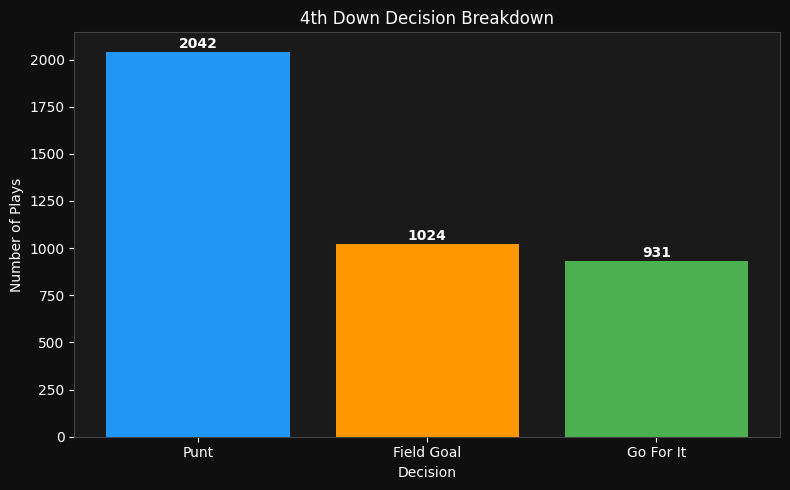

In [24]:
decision_counts = fourth_downs['decisions'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(decision_counts.index, decision_counts.values, color=['#2196F3', '#FF9800', '#4CAF50'])
plt.title('4th Down Decision Breakdown')
plt.xlabel('Decision')
plt.ylabel('Number of Plays')

for i, val in enumerate(decision_counts.values):
    plt.text(i, val +20, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

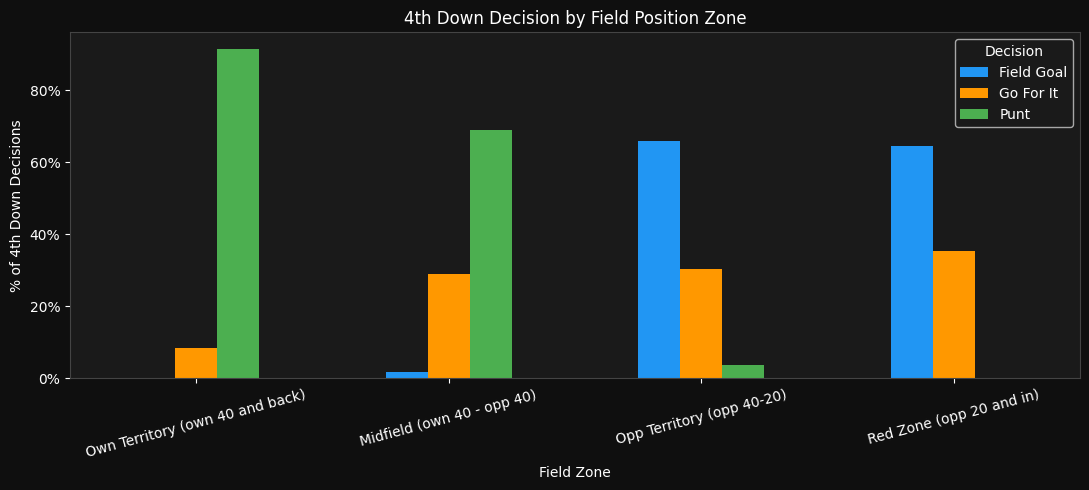

In [ ]:
zone_order = [
    'Own Territory (own 40 and back)',
    'Midfield (own 40 - opp 40)', 
    'Opp Territory (opp 40-20)',
    'Red Zone (opp 20 and in)' 
]

zone_pct = zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100
zone_pct = zone_pct.reindex(zone_order)

zone_pct.plot(kind = 'bar', figsize=(11,5), color = ['#2196F3', '#FF9800', '#4CAF50'])
plt.title('4th Down Decision by Field Position Zone')
plt.xlabel('Field Zone')
plt.ylabel('% of 4th Down Decisions')
plt.xticks(rotation=15)
plt.legend(title ='Decision')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()